# 02 — Preprocess CDFG JSON → PyG tensors


In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
from ll_hls4ml.config import load_config
from ll_hls4ml.data.tensorize import create_graph_tensors
from ll_hls4ml.data.vocab import save_vocab, vocab_scan
from ll_hls4ml.viz.dataset import analyze_graph_dataset
from ll_hls4ml.viz.eda import plot_vocab_counts


In [15]:
cfg = load_config()

kernel_subset = None  # extend as needed
max_archives = None


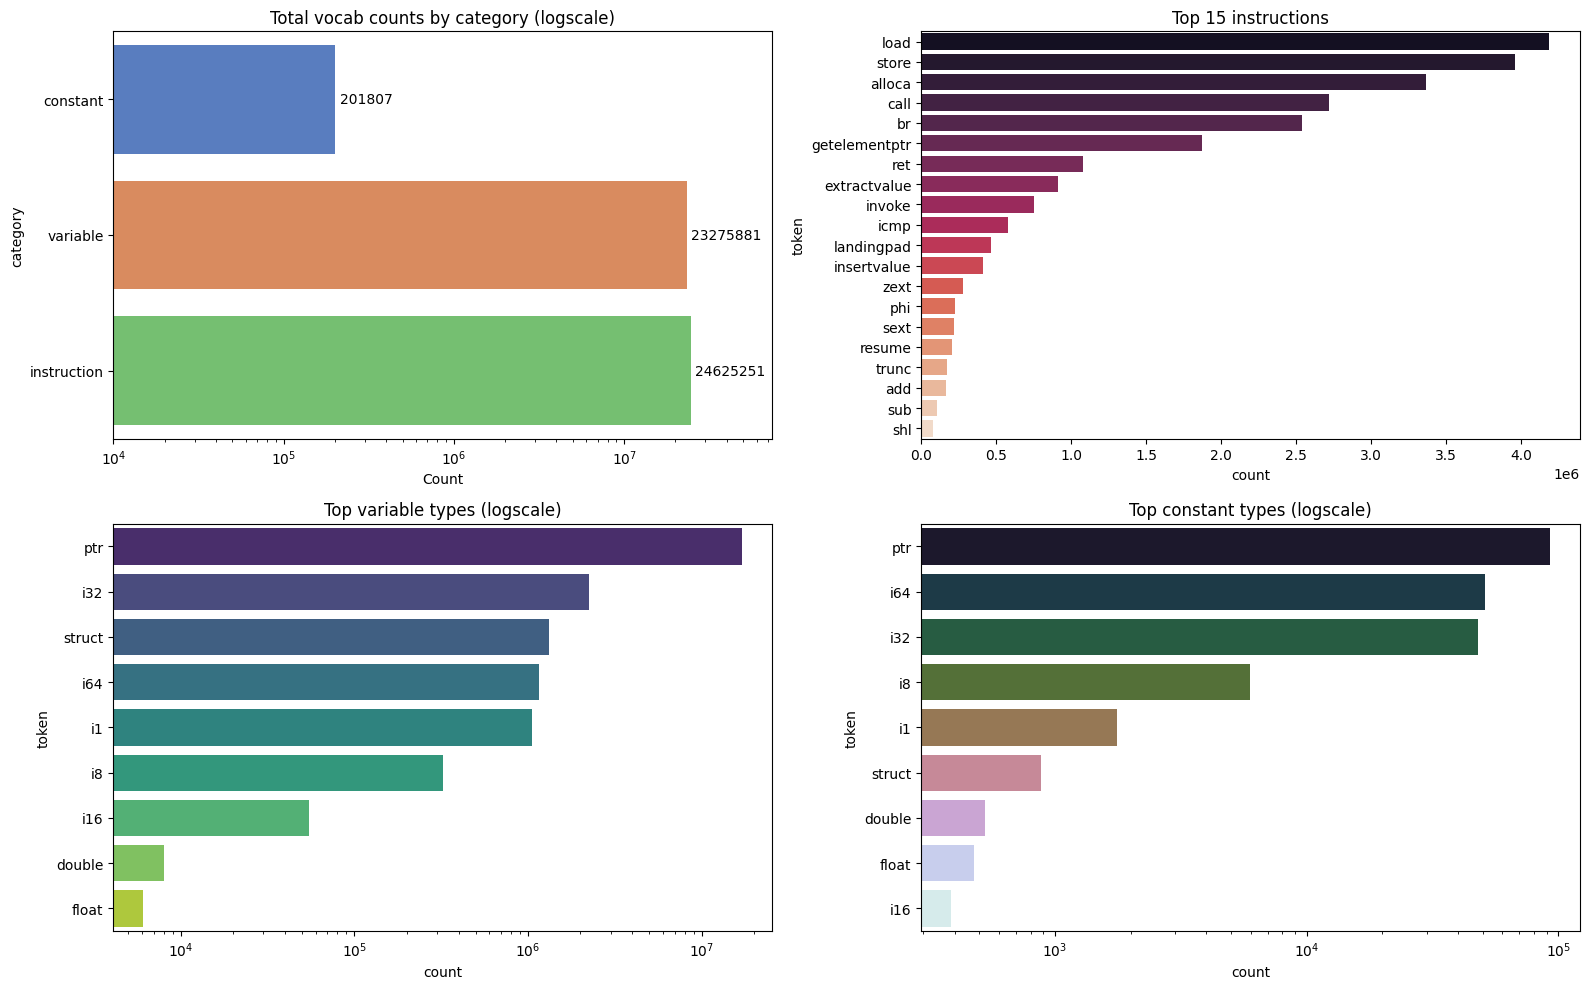

In [ ]:
vocab, max_pos, vocab_counts = vocab_scan(
    cfg.graph_dir, kernel_subset=kernel_subset, max_archives=max_archives
)
save_vocab(vocab, cfg.vocab_path, max_pos=max_pos)
plot_vocab_counts(vocab_counts)


In [ ]:
from pathlib import Path
from ll_hls4ml.data.vocab import vocab_scan_from_hls4ml_projects

programl_binary = Path("/home/brend/projects/ir_parsing/ProGraML/bazel-bin/programl/bin/llvm2graph-16")
programl_to_json_binary = Path("/home/brend/projects/ir_parsing/ProGraML/bazel-bin/programl/bin/graph2json")
clang_binary = Path("clang++-16")

pytest_dir = Path("/home/brend/hls4ml-dev/hls4ml-bambu/hls4ml/test/pytest")
pytest_vocab, pytest_max_pos, pytest_vocab_counts = vocab_scan_from_hls4ml_projects(pytest_dir, programl_binary, programl_to_json_binary, clang_binary, max_workers=8)
save_vocab(pytest_vocab, "artifacts/vocab/pytest.json", max_pos=pytest_max_pos, vocab_counts=pytest_vocab_counts)
plot_vocab_counts(pytest_vocab_counts)


In [17]:
def flatten_vocab(vocab):
    """
    Turns:
        {
          "constant": {"i32": 10, ...},
          "instruction": {"add": 5, ...}
        }

    into:
        {
          ("constant", "i32"),
          ("instruction", "add"),
          ...
        }
    """
    return {
        (category, token)
        for category, tokens in vocab.items()
        for token in tokens
    }


def compare_vocabs(vocab_left, vocab_right):
    left = flatten_vocab(vocab_left)
    right = flatten_vocab(vocab_right)

    left_only = left - right
    shared = left & right
    right_only = right - left

    return {
        "left_only": sorted(left_only),
        "shared": sorted(shared),
        "right_only": sorted(right_only),
    }


# Example
result = compare_vocabs(vocab, pytest_vocab)

print("=== LEFT ONLY ===")
for x in result["left_only"]:
    print(x)

print("\n=== SHARED ===")
for x in result["shared"]:
    print(x)

print("\n=== RIGHT ONLY ===")
for x in result["right_only"]:
    print(x)

=== LEFT ONLY ===

=== SHARED ===
('constant', 'double')
('constant', 'float')
('constant', 'i1')
('constant', 'i16')
('constant', 'i32')
('constant', 'i64')
('constant', 'i8')
('constant', 'ptr')
('constant', 'struct')
('instruction', '; undefined function')
('instruction', '[external]')
('instruction', 'add')
('instruction', 'alloca')
('instruction', 'and')
('instruction', 'ashr')
('instruction', 'br')
('instruction', 'call')
('instruction', 'extractvalue')
('instruction', 'fadd')
('instruction', 'fdiv')
('instruction', 'fmul')
('instruction', 'fneg')
('instruction', 'fpext')
('instruction', 'fptrunc')
('instruction', 'fsub')
('instruction', 'getelementptr')
('instruction', 'icmp')
('instruction', 'insertvalue')
('instruction', 'invoke')
('instruction', 'landingpad')
('instruction', 'load')
('instruction', 'lshr')
('instruction', 'mul')
('instruction', 'or')
('instruction', 'phi')
('instruction', 'ptrtoint')
('instruction', 'resume')
('instruction', 'ret')
('instruction', 'sdiv')
('i

In [34]:
shared = [term for cat, term in result["shared"]]


exclusive_pytest = {
    "instruction": 0,
    "variable": 0,
    "constant": 0,
}
for k, v in pytest_vocab_counts.items():
    for term, count in v.items():
        if term not in shared:
            exclusive_pytest[k] += count
            print(k, term, count)


# for k, v in exclusive_pytest.items():
#     print(f"Percentage of {k} terms in pytest, not found in wa-hls4ml: {v / len(pytest_vocab[k]) * 100:.2f}%")

for k, v in exclusive_pytest.items():
    print(k, v)
    print(k, sum(pytest_vocab_counts[k].values()))
    print(f"Percentage of {k} terms that would be unknown if wa-hls4ml vocab was used: {v / sum(pytest_vocab_counts[k].values()) * 100:.2f}%")


instruction fcmp 497
instruction fptosi 92
instruction uitofp 86
instruction fptoui 43
variable i48 60
variable i49 380
variable i39 1966
variable i18 140
variable i52 1216
variable i33 1103
variable i36 1900
variable i34 902
variable i37 844
variable i26 124
variable i42 1208
variable i35 1038
variable i40 381
variable i43 158
variable i44 69
variable i41 94
variable i17 140
variable i38 94
variable i3 84
variable i21 66
variable i2 90
variable i58 246
variable i24 66
constant i18 27
constant i39 72
constant i48 20
constant i49 40
constant i37 42
constant i52 48
constant i36 36
constant i33 27
constant i34 40
constant i42 60
constant i41 6
constant i40 12
constant i43 6
constant i17 30
constant i26 18
constant i44 6
constant i35 36
constant i38 6
constant i21 9
constant i3 6
constant i2 6
constant i58 9
constant i24 9
instruction 718
instruction 1899424
Percentage of instruction terms that would be unknown if wa-hls4ml vocab was used: 0.04%
variable 12369
variable 1825100
Percentage o

/home/brend/projects/ll-hls4ml/src/ll_hls4ml/viz/eda.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  import seaborn as sns
/home/brend/projects/ll-hls4ml/src/ll_hls4ml/viz/eda.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  DEFAULT_ALPHA = 0.8
/home/brend/projects/ll-hls4ml/src/ll_hls4ml/viz/eda.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  
/home/brend/projects/ll-hls4ml/src/ll_hls4ml/viz/eda.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` f

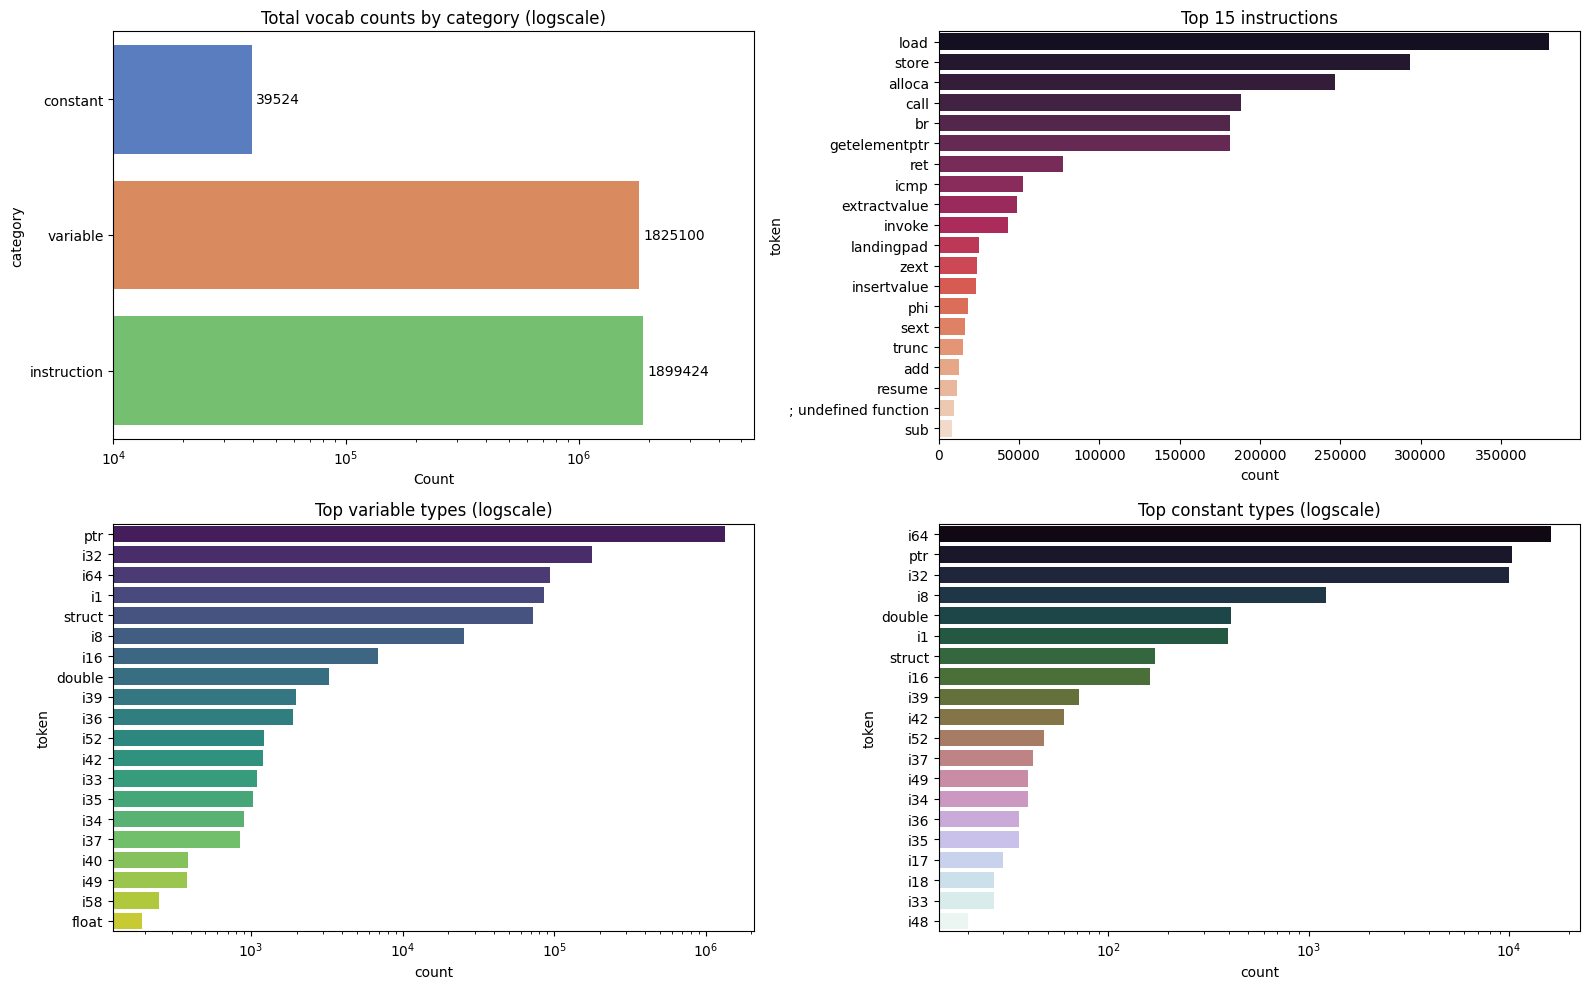

ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/home/brend/.local/lib/python3.14/site-packages/zmq/eventloop/zmqstream.py", line 565, in _log_error
    f.result()
    ~~~~~~~~^^
  File "/home/brend/.local/lib/python3.14/site-packages/ipykernel/kernelbase.py", line 584, in shell_channel_thread_main
    _, msg2 = self.session.feed_identities(msg, copy=False)
              ~~~~~~~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^
  File "/home/brend/.local/lib/python3.14/site-packages/jupyter_client/session.py", line 998, in feed_identities
    raise ValueError(msg)
ValueError: DELIM not in msg_list
ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/home/brend/.local/lib/python3.14/site-packages/zmq/eventloop/zmqstream.py", line 565, in _log_error
    f.result()
    ~~~~~~~~^^
  File "/home/brend/.local/lib/python3.14/site-packages/ipykernel/kernelbase.py", line 584, in shell_channel_thr

In [31]:
plot_vocab_counts(pytest_vocab_counts)

In [ ]:
# Uncomment to (re)build tensors for selected kernels
# for kernel in kernel_subset:
#     create_graph_tensors(
#         cfg.graph_dir, cfg.tensor_dir, vocab,
#         kernel_subset=kernel, max_archives=max_archives,
#         target_label=cfg.target_label,
#     )


In [ ]:
analyze_graph_dataset(cfg.tensor_dir)
